[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/02_custom_cnn.ipynb)

# Custom CNN

**CSC3109 - Machine Learning | Team 16 — Member 1**

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally — skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED, TRAIN_RATIO
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Split  : {TRAIN_RATIO:.0%} train / {1-TRAIN_RATIO:.0%} val")
print("Policy : 70/30 split inside each class folder in data/set 16")

ROOT   : /content/CSC3109-T16-Project
Device : cuda
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Split  : 70% train / 30% val
Policy : 70/30 split inside each class folder in data/set 16


In [4]:
import torch
import torch.optim as optim

from src.dataset import get_dataloaders
from src.models import get_custom_cnn
from src.train import train
from src.evaluate import get_predictions, compute_metrics, print_report, plot_confusion_matrix
from src.utils import count_parameters, plot_training_curves, save_metrics_to_csv

# load dataset
train_loader, val_loader, class_names = get_dataloaders(
    root=ROOT,
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    train_ratio=TRAIN_RATIO,
    seed=SEED,
    num_workers=2
)

print("Classes:", class_names)
print("Train images:", len(train_loader.dataset))
print("Val images:", len(val_loader.dataset))

# create custom CNN model
model = get_custom_cnn(num_classes=NUM_CLASSES).to(DEVICE)

print(model)
print("Trainable parameters:", count_parameters(model))

# optimizer + scheduler
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

# train and save best model
save_model_path = ROOT / "results" / "saved_models" / "custom_cnn.pth"

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    save_path=save_model_path
)

print("Training done.")
print("Best model saved to:", save_model_path)

Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Train images: 1960
Val images: 840
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

Training curves saved to /content/CSC3109-T16-Project/results/training_curves/custom_cnn_training_curve.png


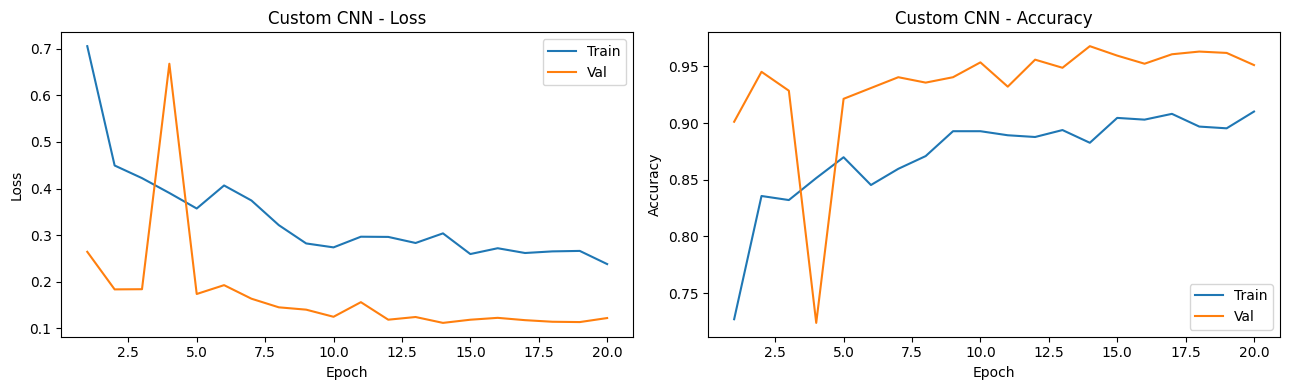

Custom CNN Metrics:
accuracy: 0.9679
precision: 0.9703
recall: 0.9679
f1_score: 0.9676

Classification Report:
                precision    recall  f1-score   support

         beach       0.99      1.00      1.00       210
ferry_terminal       0.99      0.88      0.93       210
        harbor       0.90      1.00      0.95       210
         river       1.00      1.00      1.00       210

      accuracy                           0.97       840
     macro avg       0.97      0.97      0.97       840
  weighted avg       0.97      0.97      0.97       840

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/custom_cnn_confusion_matrix.png


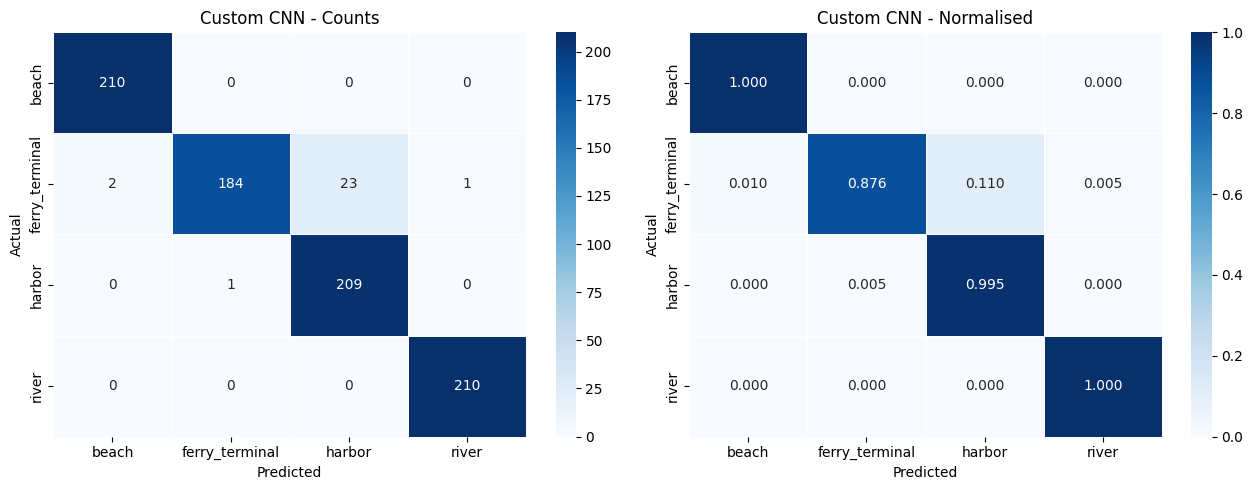

Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Saved training curve to: /content/CSC3109-T16-Project/results/training_curves/custom_cnn_training_curve.png
Saved confusion matrix to: /content/CSC3109-T16-Project/results/confusion_matrices/custom_cnn_confusion_matrix.png
Saved metrics to: /content/CSC3109-T16-Project/results/metrics.csv


In [5]:
# load the best saved model
model = get_custom_cnn(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(save_model_path, map_location=DEVICE))
model = model.to(DEVICE)

# save training curve
curve_path = ROOT / "results" / "training_curves" / "custom_cnn_training_curve.png"

plot_training_curves(
    history,
    title="Custom CNN",
    save_path=curve_path
)

# get predictions
y_pred, y_true = get_predictions(model, val_loader, DEVICE)

# compute metrics
metrics = compute_metrics(y_true, y_pred)

print("Custom CNN Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

print("\nClassification Report:")
print_report(y_true, y_pred, class_names)

# save confusion matrix
cm_path = ROOT / "results" / "confusion_matrices" / "custom_cnn_confusion_matrix.png"

plot_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
    title="Custom CNN",
    save_path=cm_path
)

# save metrics CSV
metrics_path = ROOT / "results" / "metrics.csv"

save_metrics_to_csv(
    model_name="custom_cnn",
    metrics=metrics,
    csv_path=metrics_path
)

print("Saved training curve to:", curve_path)
print("Saved confusion matrix to:", cm_path)
print("Saved metrics to:", metrics_path)

In [6]:
!find results -maxdepth 3 -type f | sort

results/confusion_matrices/custom_cnn_confusion_matrix.png
results/confusion_matrices/.gitkeep
results/metrics.csv
results/saved_models/custom_cnn.pth
results/training_curves/custom_cnn_training_curve.png
results/training_curves/.gitkeep
